# Tutorial 4: GRN Analysis

After training, we can extract and analyze the learned Gene Regulatory Network. The model learns two regulatory matrices:

- **tf2r (TF→Region)**: Which TFs bind to which regulatory regions
- **r2g (Region→Gene)**: Which regions regulate which genes

This tutorial shows how to extract these matrices and find key regulatory relationships.

## Setup

In [2]:
import torch

import deepscenic as ds

print(f"deepSCENIC version: {ds.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

deepSCENIC version: 0.1.0
Using device: cuda


## Load Model and Data

In [3]:
data_dir = "/data/groups/vib.ai/stein.aerts/gpartel/data/MM_lines_demo/"

# Load trained model and data
model = ds.tl.load_model(data_dir + "checkpoints/deepscenic_model.pt", device=device)
mdata = ds.read(data_dir + "preprocessed_data.h5mu")

print(f"Model: {len(model.tf_names)} TFs, {len(model.gene_names)} genes")

2026-08-18 13:00:07.476651: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-18 13:00:07.485634: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787050807.495182 1559066 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787050807.497953 1559066 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787050807.505620 1559066 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Model: 1446 TFs, 12109 genes


We expect certain TFs to be active in specific cell states:

| Cell State | Expected state-associated TFs |
|------------|-------------------|
| **MEL** | MITF, TFAP2A, RUNX3 |
| **INT** | SOX10, EGR3, ETV4 |
| **MES** | JUN, NFIB, ZEB1 |

We first identify enhancers with significantly different model-predicted activity in each cell state. Scores are z-score normalized across cell states separately for each TF. The resulting values therefore show the relative state preference (specificity) of each TF, rather than its absolute activity.


In [28]:
# Identify regions with differential model-derived enhancer activity in each cell state.
active_enh = ds.tl.identify_active_enhancers(model, mdata, class_key="cell_state")

# Calculate TF activity scores using each state's active enhancers, then z-score each TF across cell states.
tf_scores = ds.tl.compute_tf_activity_scores(
    model, mdata, class_key="cell_state", active_enhancers=active_enh, zscore=True
)

/data/groups/vib.ai/stein.aerts/gpartel/software/miniconda3/envs/deepSCENIC/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/data/groups/vib.ai/stein.aerts/gpartel/software/miniconda3/envs/deepSCENIC/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/data/groups/vib.ai/stein.aerts/gpartel/software/miniconda3/envs/deepSCENIC/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
deepscenic.tl._grn - INFO - Cell type 'MEL': 3000 active enhancers
deepscenic.tl._grn - INFO - Cell type 'MES': 3000 active enhancers
deepscenic.tl._grn - INFO - Cell type 'INT': 3000 active enhancers


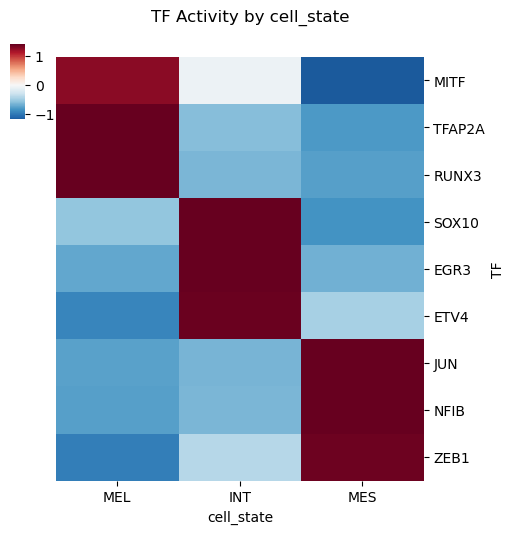

In [29]:
# Visualize selected TFs with known melanoma-state associations.
# Rows are kept in the biologically defined order shown in the table.
state_tfs = [
    "MITF",
    "TFAP2A",
    "RUNX3",  # MEL
    "SOX10",
    "EGR3",
    "ETV4",  # INT
    "JUN",
    "NFIB",
    "ZEB1",  # MES
]


ds.pl.tf_activity_clustermap(
    tf_scores.loc[state_tfs, ["MEL", "INT", "MES"]], xlabel="cell_state", cluster_rows=False, figsize=(5, 5)
)

In [ ]:
# Step 6: Build a focused GRN for the state TFs
focused_grn = ds.tl.build_grn_for_tfs(model, state_tfs)
print(f"Focused GRN: {len(focused_grn)} edges")
focused_grn.head(10)

deepscenic.tl._grn - INFO - TF 'MITF': using Otsu tf2r threshold = 1.0275
deepscenic.tl._grn - INFO - TF 'TFAP2A': using Otsu tf2r threshold = 0.1618
deepscenic.tl._grn - INFO - TF 'RUNX3': using Otsu tf2r threshold = 0.2603
deepscenic.tl._grn - INFO - TF 'SOX10': using Otsu tf2r threshold = 0.7598
deepscenic.tl._grn - INFO - TF 'EGR3': using Otsu tf2r threshold = 0.0156
deepscenic.tl._grn - INFO - TF 'ETV4': using Otsu tf2r threshold = 0.1692
deepscenic.tl._grn - INFO - TF 'JUN': using Otsu tf2r threshold = 0.0067
deepscenic.tl._grn - INFO - TF 'NFIB': using Otsu tf2r threshold = 0.0041


## Network Visualization

Network graphs show the GRN structure as connected nodes.

In [ ]:
# Visualize full GRN as network
ds.pl.network_grn(model, top_k=50)

In [ ]:
# TF-centric network: show targets of a specific TF
ds.pl.network_tf_targets(model, tf="SOX10", top_k=20)

In [ ]:
# Gene-centric network: show regulators of a specific gene
ds.pl.network_gene_regulators(model, gene="MITF", top_k=10)

## Extract the full GRN

The deepSCENIC gene regulatory network consists of two components:

- **tf2r (TF → region):** A dense matrix of learned TF-binding scores, with transcription factors as rows and regulatory regions as columns.
- **r2g (region → gene):** A sparse region-to-gene network. It is returned as an edge-list DataFrame with three columns:
  - `region`: regulatory-region name
  - `gene`: target-gene name
  - `weight`: learned region-to-gene regulatory weight

Each row of the `r2g` DataFrame represents one candidate region–gene link. Its shape is therefore `(n_links, 3)`, not `(n_regions, n_genes)`. This sparse representation avoids constructing a potentially very large dense matrix.

Conceptually, the TF-to-gene regulatory network is obtained by composing the two components:

```text
TF → region → gene
```

or, in matrix notation:

```text
tf2r @ r2g
```

This produces TF-to-gene regulatory scores by combining TF-binding potential with region-to-gene effects.

The extracted `tf2r` matrix has shape `TFs × regions`, while `r2g` is conceptually `regions × genes`. Their multiplication therefore produces a `TFs × genes` regulatory matrix.

In [4]:
# Extract the full GRN as a DataFrame
# Returns dict with 'tf2r', 'r2g' DataFrames
grn = ds.tl.extract_grn(model)

print(f"tf2r (TF→Region): {grn['tf2r'].shape}")
print(f"r2g (Region→Gene): {grn['r2g'].shape}")

tf2r (TF→Region): (1446, 288552)
r2g (Region→Gene): (3245122, 3)


## Find TF Targets

Get the target genes for a specific TF, ranked by regulatory weight.

**r2g normalization**: By default, r2g weights are normalized per gene so they sum to 1.
This means each weight represents the *fractional contribution* of that region to the gene's
regulatory signal (in [0, 1]). This makes weights comparable across genes, which have
different numbers of linked enhancers and different expression scales.

In [5]:
# Find targets of a TF
# Uses Otsu thresholding to identify significant links
targets = ds.tl.get_tf_targets(model, tf_name="MITF")
targets.sort_values("combined_weight", ascending=False)

deepscenic.tl._grn - INFO - TF 'MITF': using Otsu tf2r threshold = 1.0275


,tf,region,tf2r_weight,gene,r2g_weight,combined_weight
26311,MITF,chrX:72461632-72462132,4.203068,CITED1,0.621780,2.613386
112007,MITF,chr7:29090974-29091474,2.888003,CPVL,0.499723,1.443202
46598,MITF,chr8:93794556-93795056,3.700871,ESRP1,0.379980,1.406255
89583,MITF,chr10:127314238-127314738,2.243870,C10orf90,0.625499,1.403538
113441,MITF,chr2:231710-232210,1.990901,SH3YL1,0.640161,1.274497
...,...,...,...,...,...,...
90185,MITF,chr10:77513710-77514210,-2.608505,KCNMA1,0.467669,-1.219917
72590,MITF,chr1:164772616-164773116,-1.632521,PBX1,0.761452,-1.243086
89209,MITF,chr21:45366902-45367402,-2.123974,COL6A2,0.591197,-1.255687
74022,MITF,chr9:79764351-79764851,-1.694671,TLE4,0.859286,-1.456208


## Find Gene Regulators

Get the TFs that regulate a specific gene. r2g weights are normalized per gene (sum to 1),
so they represent each region's fractional contribution to the gene's regulatory signal.

Here, we use PMEL as an example. PMEL is a melanocyte-lineage gene required for melanosome formation and normal pigmentation. Its expression is expected to be controlled by key melanocytic master regulators. Consistently, deepSCENIC identifies MITF as the strongest positive regulator of PMEL, with SOX10 also among the top predicted regulators, recovering the expected melanocyte regulatory program.

In [8]:
# Find regulators of a gene
regulators = ds.tl.get_gene_regulators(model, gene_name="IRF4", top_k=10)
regulators

deepscenic.tl._grn - INFO - Gene 'IRF4': using per-TF Otsu thresholds


,gene,tf,region,tf2r_weight,r2g_weight,combined_weight
8696,IRF4,MITF,chr6:396072-396572,4.708549,0.248430,1.169746
8798,IRF4,PIR,chr6:396072-396572,4.410172,0.248430,1.095620
8336,IRF4,ANXA1,chr6:396072-396572,-3.997245,0.248430,-0.993037
8907,IRF4,SOX10,chr6:396072-396572,2.877899,0.248430,0.714957
8716,IRF4,MXI1,chr6:396072-396572,2.374235,0.248430,0.589832
8602,IRF4,ID2,chr6:396072-396572,2.025816,0.248430,0.503274
8807,IRF4,POLR3G,chr6:396072-396572,1.981801,0.248430,0.492339
9066,IRF4,ZCCHC17,chr6:396072-396572,1.960231,0.248430,0.486981
8411,IRF4,CTNNB1,chr6:396072-396572,1.398108,0.248430,0.347332
22398,IRF4,MITF,chr6:487907-488407,4.488799,0.076773,0.344619


## Query a Region

`get_region_info` answers the question: *"Given a regulatory region, which TFs bind here and which genes does it regulate?"*

This complements the TF-centric (`get_tf_targets`) and gene-centric (`get_gene_regulators`) queries
with a region-centric view. It returns TF→region→gene paths for any set of regions.

In [7]:
# Use the top region from MITF targets as an example
region = targets.iloc[0]["region"]
print(f"Querying region: {region}")

# Get top active TFs and target genes for this region
region_info = ds.tl.get_region_info(model, region, top_k_tfs=5, top_k_genes=5)
region_info

Querying region: chrX:72461632-72462132


,region,tf,tf2r_weight,gene,r2g_weight
0,chrX:72461632-72462132,PIR,4.636881,CITED1,0.621780
1,chrX:72461632-72462132,PIR,4.636881,PHKA1,0.022362
2,chrX:72461632-72462132,PIR,4.636881,NAP1L2,0.014567
3,chrX:72461632-72462132,PIR,4.636881,HDAC8,0.002616
4,chrX:72461632-72462132,PIR,4.636881,OGT,0.000870
5,chrX:72461632-72462132,MITF,4.203068,CITED1,0.621780
6,chrX:72461632-72462132,MITF,4.203068,PHKA1,0.022362
7,chrX:72461632-72462132,MITF,4.203068,NAP1L2,0.014567
8,chrX:72461632-72462132,MITF,4.203068,HDAC8,0.002616
9,chrX:72461632-72462132,MITF,4.203068,OGT,0.000870


## Visualize GRN Heatmaps

The combined GRN heatmap shows the TF→gene regulatory weights (tf2r @ r2g), z-score normalized
per TF to highlight gene-specific patterns. For cell-type specific visualization, see the
cell-type aware workflow below.

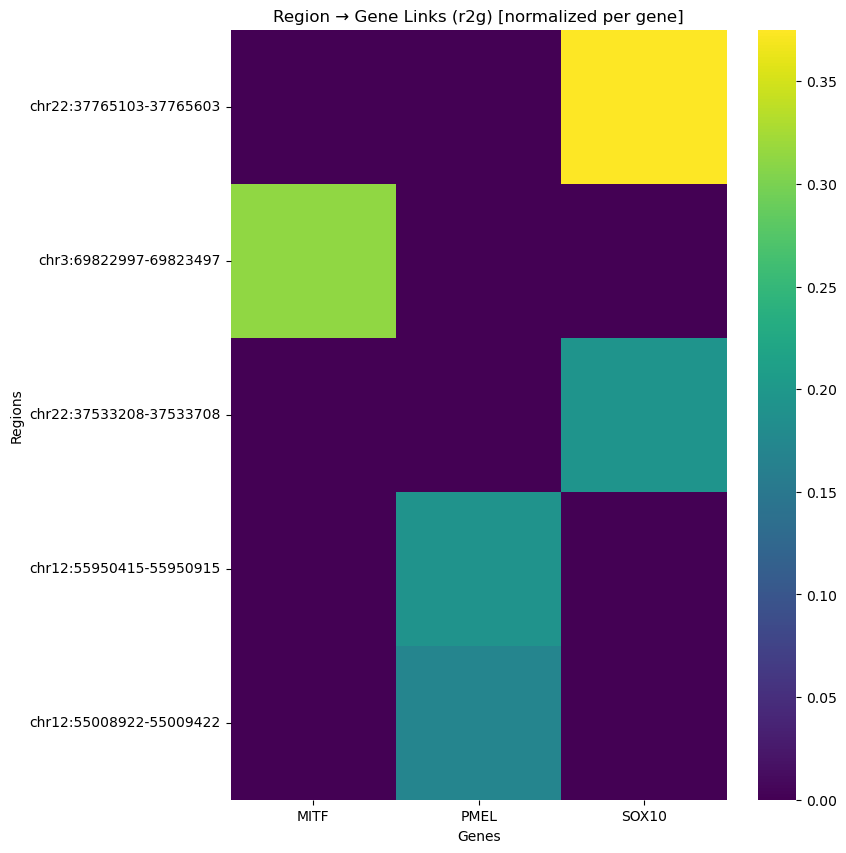

In [6]:
# r2g heatmap (Region->Gene)
ds.pl.heatmap_r2g(
    model,
    genes=["MITF", "SOX10", "PMEL"],
    top_k=5,  # retain the 5 strongest regions across these genes
    normalize=True,
    figsize=(8, 10),
)

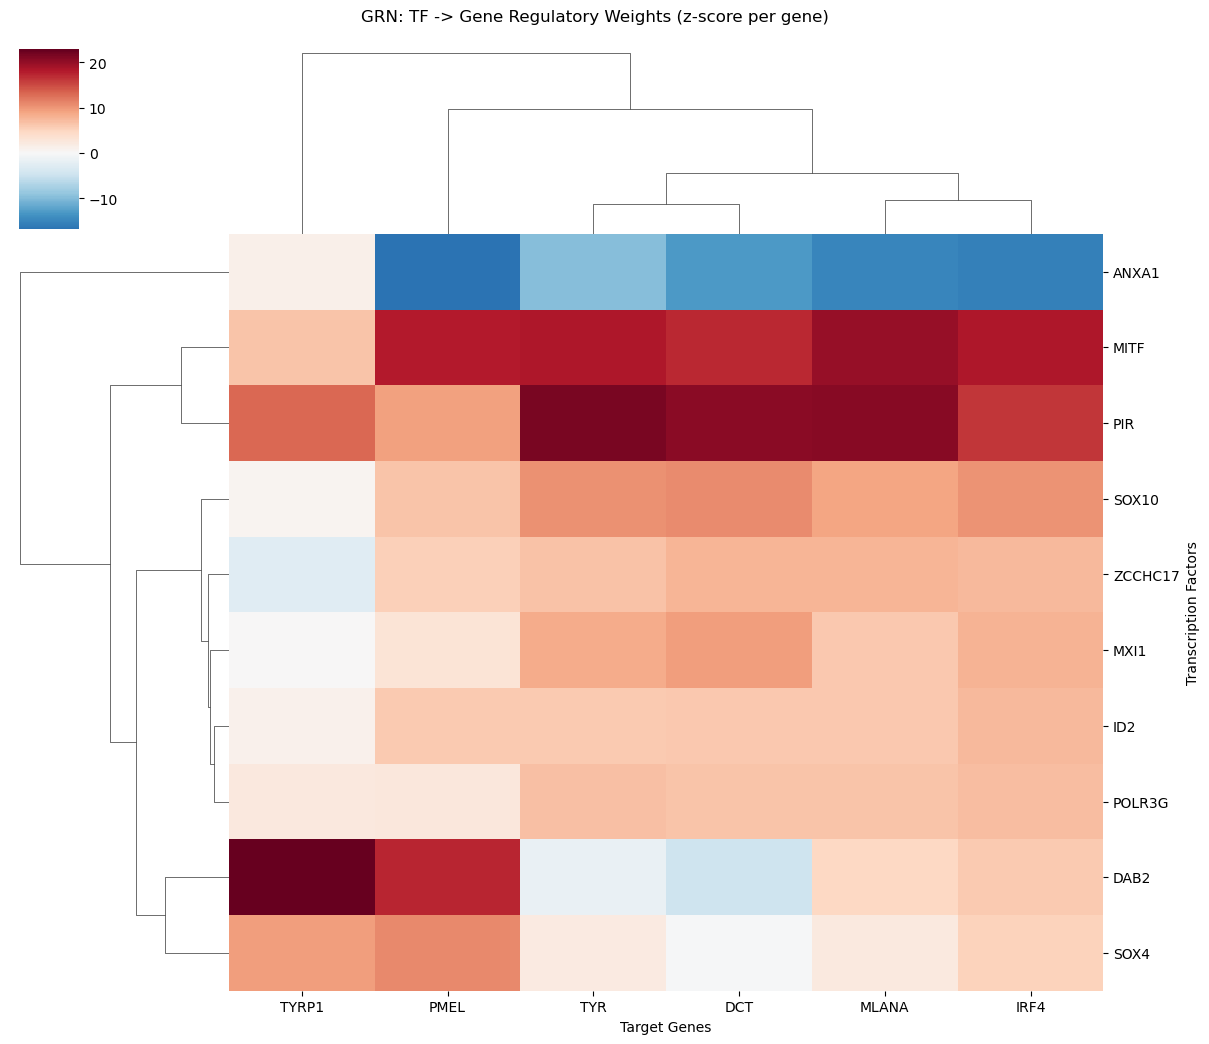

In [8]:
# Combined GRN heatmap (TF->Gene), z-score normalized per gene
ds.pl.heatmap_grn(
    model,
    genes=["TYR", "TYRP1", "DCT", "MLANA", "PMEL", "IRF4"],
    normalize="gene",
    top_k=10,
)

## Cell-type-specific GRN Analysis

The GRN extracted in the previous sections represents a **global regulatory network**.  
Its TF–region (`tf2r`) and region–gene (`r2g`) relationships are learned using information from all cells in the dataset and therefore describe the overall regulatory architecture supported by the full cellular population.

However, the activity of this regulatory architecture depends on the **cellular context**. In particular, transcription factors are expressed at different levels across cell types, meaning that a regulatory interaction encoded in the global GRN may be highly relevant in one cell type but effectively inactive in another.

We therefore derive **cell-type-specific GRNs** by combining the global `tf2r` and `r2g` regulatory scores with cell-type-specific information, most importantly the observed expression of TFs in each cell type. In this way, the global GRN provides the underlying regulatory potential, while TF expression determines which parts of that network are active in a given cellular context.

Conceptually:

```text
Global regulatory potential
TF ──tf2r──> region ──r2g──> gene
        +
Cell-type-specific TF expression
        ↓
Cell-type-specific regulatory activity

```

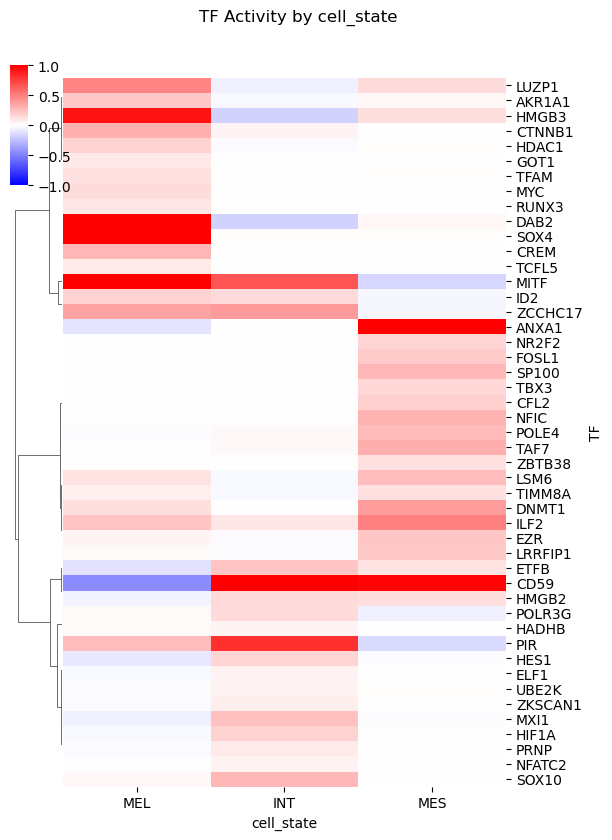

In [23]:
# Step 1: Identify differentially active enhancers per cell type (Wilcoxon)
active_enhancers = ds.tl.identify_active_enhancers(model, mdata, class_key="cell_state")

# Step 2: Compute TF activity scores weighted by active enhancers
tf_scores = ds.tl.compute_tf_activity_scores(
    model, mdata, class_key="cell_state", active_enhancers=active_enhancers, zscore=False
)

# Step 3: Select the top positive TFs in each class and take their union
top_tfs_by_class = {cell_class: tf_scores[cell_class].nlargest(20).index.tolist() for cell_class in tf_scores.columns}

selected_tfs = list(dict.fromkeys(tf for cell_class in tf_scores.columns for tf in top_tfs_by_class[cell_class]))

# Step 4: plot cell-type specific TFs
ds.pl.tf_activity_clustermap(
    tf_scores.loc[:, ["MEL", "INT", "MES"]],
    tfs=selected_tfs,
    xlabel="cell_state",
    cluster_rows=True,
    cluster_cols=False,
    cmap="bwr",
    center=0,
    method="average",
    metric="correlation",
    vmin=-1,
    vmax=1,
    figsize=(6, 8),
)

### Inspect cell-type-specific regulatory links

The functions below combine the learned global GRN with the mean latent activity of one cell class. Here, we use the melanocytic (`MEL`) state and return edge lists so that the original network weight, mean class activity, and resulting cell-type-specific score can be inspected separately. If latent activities are not already stored in `mdata.obsm`, they are computed automatically with `ds.tl.to_latent`.

- `compute_celltype_tf2r` scores TF→region links using mean TF activity.
- `compute_celltype_r2g` scores region→gene links using mean enhancer activity.
- `compute_celltype_tf2g` combines TF→region and region→gene weights, then scores TF→gene links using mean TF activity.

Set `as_edgelist=False` to obtain the corresponding dense matrix instead. The examples retain signed scores and rank links by absolute magnitude.

In [5]:
cell_class = "MEL"

mel_tf2r = ds.tl.compute_celltype_tf2r(
    model,
    mdata,
    class_key="cell_state",
    class_label=cell_class,
    as_edgelist=True,
)

mel_r2g = ds.tl.compute_celltype_r2g(
    model,
    mdata,
    class_key="cell_state",
    class_label=cell_class,
    as_edgelist=True,
    normalize_r2g=True,
)

mel_tf2g = ds.tl.compute_celltype_tf2g(
    model,
    mdata,
    class_key="cell_state",
    class_label=cell_class,
    as_edgelist=True,
    normalize_r2g=True,
)

Extracting embeddings:   0%|          | 0/4 [00:00<?, ?it/s]

In [6]:
from IPython.display import display


def strongest_links(edges, score_column, n=10):
    strongest = edges[score_column].abs().nlargest(n).index
    return edges.loc[strongest].sort_values(score_column, ascending=False)


print(f"Strongest TF→region links in {cell_class}")
display(strongest_links(mel_tf2r, "celltype_tf2r_weight"))

print(f"Strongest region→gene links in {cell_class}")
display(strongest_links(mel_r2g, "celltype_r2g_weight"))

print(f"Strongest TF→gene links in {cell_class}")
display(strongest_links(mel_tf2g, "celltype_tf2g_weight"))

Strongest TF→region links in MEL


,tf,region,tf2r_weight,tf_activity,celltype_tf2r_weight
413439352,MITF,chr1:30786516-30787016,10.315485,4.552557,46.961834
197859550,MITF,chr1:157033995-157034495,9.882759,4.552557,44.991825
398395168,MITF,chr5:38147912-38148412,9.618464,4.552557,43.788609
210024748,MITF,chr1:26028396-26028896,8.826521,4.552557,40.183239
412570306,MITF,chr3:181752176-181752676,8.791292,4.552557,40.022858
121758016,MITF,chr1:33005485-33005985,8.744653,4.552557,39.810532
392524408,MITF,chr2:121884566-121885066,8.723854,4.552557,39.715843
61506088,MITF,chr2:48205188-48205688,8.672826,4.552557,39.483532
298266898,MITF,chr15:100224492-100224992,8.608095,4.552557,39.188843
311626492,MITF,chr4:139783922-139784422,8.585516,4.552557,39.086052


Strongest region→gene links in MEL


,region,gene,r2g_weight,enhancer_activity,celltype_r2g_weight
637005,chrX:72461632-72462132,CITED1,0.621780,65.672928,40.834145
2752844,chr7:29090974-29091474,CPVL,0.499723,65.907333,32.935413
1128396,chr1:110177662-110178162,SORT1,0.356980,65.374916,23.337517
1382404,chr10:845482-845982,DIP2C,0.255060,91.167709,23.253265
823675,chr18:66603943-66604443,CDH19,0.329725,69.090126,22.780712
1132913,chr8:93794556-93795056,ESRP1,0.379980,55.255215,20.995855
432344,chr6:396072-396572,IRF4,0.248430,84.462135,20.982950
1822492,chrX:9729080-9729580,GPR143,0.433584,47.599571,20.638395
162743,chr13:49299120-49299620,SETDB2,0.251200,77.755363,19.532148
43223,chr3:125975226-125975726,ROPN1B,0.399002,48.807991,19.474478


Strongest TF→gene links in MEL


,tf,gene,tf2g_weight,tf_activity,celltype_tf2g_weight
4785292,MITF,CITED1,2.620873,4.552557,11.931676
542728,MITF,IRF4,2.092678,4.552557,9.527036
5176798,DAB2,CPVL,2.032801,4.593024,9.336705
263650,MITF,ESRP1,1.663668,4.552557,7.573941
9479008,MITF,LZTS1,1.610113,4.552557,7.330132
5768572,MITF,DIP2C,1.584069,4.552557,7.211565
14012218,MITF,SGCD,1.567323,4.552557,7.135328
3421714,MITF,BAMBI,1.567002,4.552557,7.133866
5177158,MITF,CPVL,1.539539,4.552557,7.008839
14505304,MITF,SLC8A1,-1.634983,4.552557,-7.443354


## Visualize regulatory links in genomic context

A GRN edge list identifies linked regions and genes, but it does not immediately show where those regions lie relative to the target gene or whether they are accessible in different cell states. The following examples place the normalized global region-to-gene links for **IRF4** back onto their genomic coordinates.

`ds.pl.genome_browser` combines several aligned tracks in one view:

- aggregated chromatin accessibility for MEL and MES cells;
- the IRF4 transcription start site;
- the strongest normalized global region-to-IRF4 links.

The displayed window is determined from the strongest linked regions rather than being hard-coded. Links are extracted with `normalize=True`, so the `weight` column represents each region's fractional contribution to IRF4 and sums to one across all modeled IRF4 links. Darker arcs represent larger contributions. MEL and MES accessibility are shown separately, preserving a clear distinction between global network structure and cell-state-specific chromatin accessibility.

In [4]:
import numpy as np
import pandas as pd

target_gene = "IRF4"
gene_row = mdata.mod["rna"].var.loc[target_gene]
gene_chrom = str(gene_row["chromosome"])
gene_tss = int(gene_row["tss"])

global_r2g = ds.tl.extract_r2g_matrix(model, as_edgelist=True, normalize=True)
irf4_links = global_r2g.loc[global_r2g["gene"] == target_gene].copy()
region_coordinates = irf4_links["region"].apply(ds.pl.parse_region)
irf4_links[["chrom", "region_start", "region_end"]] = pd.DataFrame(region_coordinates.tolist(), index=irf4_links.index)

# Chromosome prefixes can differ between gene annotations and region names.
same_chromosome = irf4_links["chrom"].str.removeprefix("chr") == gene_chrom.removeprefix("chr")
irf4_links = irf4_links.loc[same_chromosome].copy()
irf4_links["weight"] = irf4_links["weight"].abs()
irf4_links = irf4_links.nlargest(25, "weight")

view_chrom = irf4_links["chrom"].iloc[0]
view_start = max(0, min(gene_tss, irf4_links["region_start"].min()) - 10_000)
view_end = max(gene_tss, irf4_links["region_end"].max()) + 10_000
gene_strand = gene_row["strand"] if "strand" in gene_row and pd.notna(gene_row["strand"]) else "+"

gene_annotation = pd.DataFrame(
    {
        "gene": [target_gene],
        "chrom": [view_chrom],
        "start": [gene_tss],
        "end": [gene_tss + 1_000],
        "strand": [gene_strand],
    }
)
browser_links = irf4_links[["region", "gene", "weight"]]

cell_groups = {state: np.flatnonzero(mdata.obs["cell_state"].to_numpy() == state) for state in ["MEL", "MES"]}
group_colors = {"MEL": "#E64B35", "MES": "#4DBBD5"}

print(f"Showing {len(browser_links)} links across {view_chrom}:{view_start:,}-{view_end:,}")

Showing 25 links across chr6:214,080-1,308,133


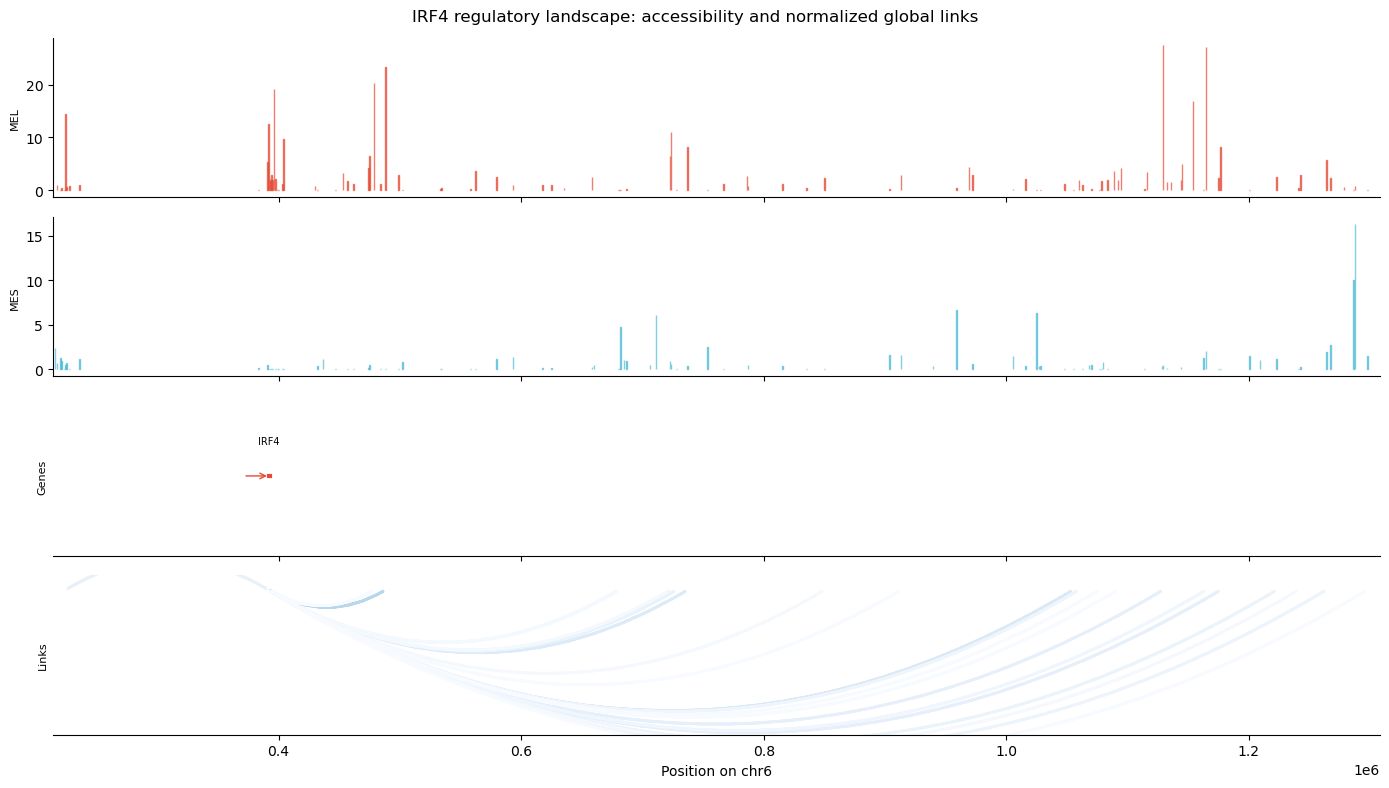

In [5]:
ds.pl.genome_browser(
    mdata,
    chrom=view_chrom,
    start=view_start,
    end=view_end,
    genes=gene_annotation,
    links=browser_links,
    cell_groups=cell_groups,
    group_colors=group_colors,
    link_alpha=1.0,
    link_width=2.0,
    title="IRF4 regulatory landscape: accessibility and normalized global links",
    figsize=(14, 8),
)

## Next Steps

Now that you've extracted and visualized the GRN:

- Simulate perturbation experiments: {doc}`05_perturbation_analysis`
- Explore advanced genomic visualizations: {doc}`06_advanced_visualization`